<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Нейронні мережі, Чуркін Дмитро ФІТ 3-15

Був присутній на парі

Завдання 1. Побудувати нейронну мережу для класифікації типів одягу.
Для цього завантажити датасет, нормалізувати дані.
Побудувати модель, вивести архітектуру, використати ранню зупинку та зменшення швидкості навчання, побудувати графіки точності та функції втрат, вивести візуалізацію класифікації (картинка, справжній та прогнозований клас)

Завдання 2. Підібрати параметри моделі для моделі

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7880 - loss: 0.5898 - val_accuracy: 0.8238 - val_loss: 0.4491 - learning_rate: 0.0010
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8404 - loss: 0.4343 - val_accuracy: 0.8625 - val_loss: 0.3773 - learning_rate: 0.0010
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8545 - loss: 0.4011 - val_accuracy: 0.8685 - val_loss: 0.3644 - learning_rate: 0.0010
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8609 - loss: 0.3783 - val_accuracy: 0.8639 - val_loss: 0.3677 - learning_rate: 0.0010
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8664 - loss: 0.3627 - val_accuracy: 0.8774 - val_loss: 0.3441 - learning_rate: 0.0010
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8717 - loss: 0.3503 - val_accuracy: 0.8732 - val_loss: 0.3438 - learning_rate: 0.0010
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8745 - l

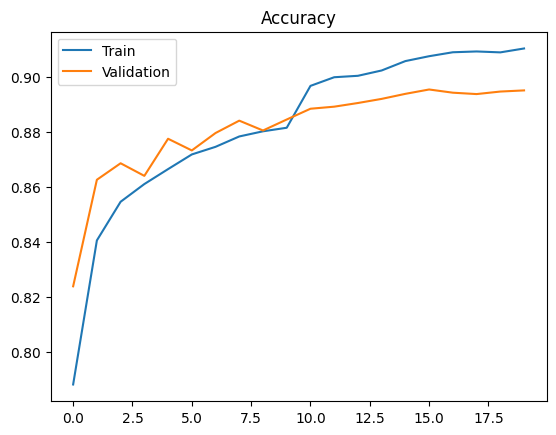

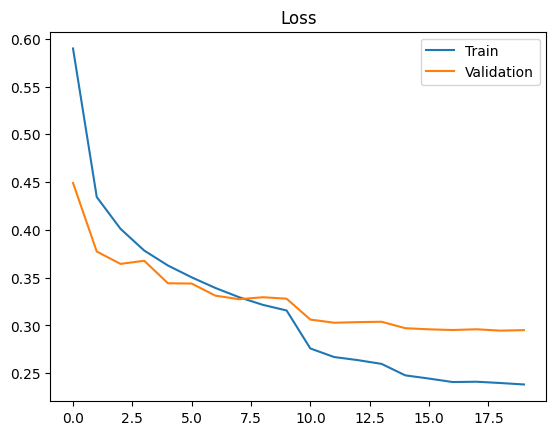

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


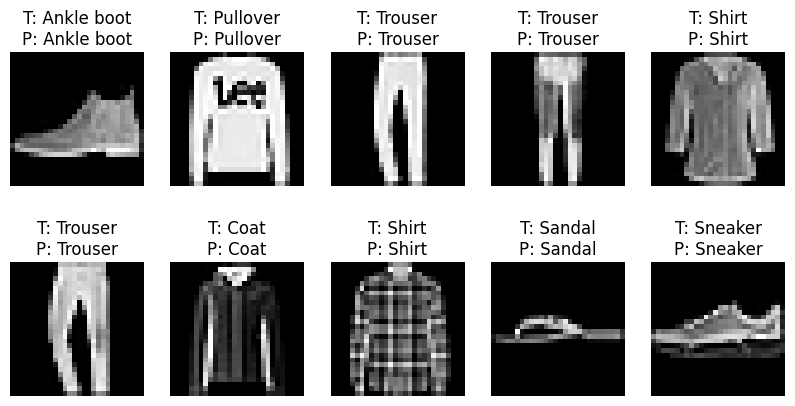

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Завантаження датасету
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 2. Нормалізація
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Побудова моделі
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 4. Компіляція
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

# 6. Навчання
history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 7. Оцінка
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest accuracy:", test_acc)

# 8. Графіки
plt.figure()
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()
plt.show()

# 9. Візуалізація прогнозів
predictions = model.predict(x_test)

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i]]
    plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.axis('off')

plt.show()

In [3]:
# Інша архітектура
model2 = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

test_loss2, test_acc2 = model2.evaluate(x_test, y_test)

print("\nModel 1 accuracy:", test_acc)
print("Model 2 accuracy:", test_acc2)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7934 - loss: 0.5744 - val_accuracy: 0.8382 - val_loss: 0.4343
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8352 - loss: 0.4482 - val_accuracy: 0.8568 - val_loss: 0.3906
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8470 - loss: 0.4140 - val_accuracy: 0.8630 - val_loss: 0.3728
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8359 - loss: 0.4565

Model 1 accuracy: 0.891700029373169
Model 2 accuracy: 0.8359000086784363


Висновки:

У ході лабораторної роботи було побудовано та досліджено нейронну мережу для задачі класифікації з використанням датасету Fashion MNIST. Дані було попередньо нормалізовано, що дозволило підвищити стабільність та швидкість навчання моделі.

Було реалізовано багатошарову нейронну мережу з використанням функції активації ReLU та методу оптимізації Adam. Для запобігання перенавчанню застосовано механізми ранньої зупинки (EarlyStopping) та зменшення швидкості навчання (ReduceLROnPlateau). Аналіз графіків точності та функції втрат показав, що модель добре узагальнює дані та не демонструє значного перенавчання.
Додатково проведено експериментальне дослідження в середовищі TensorFlow Playground, яке дозволило наочно побачити процес навчання нейронної мережі та формування нелінійних меж класифікації. Було встановлено, що нейронні мережі здатні ефективно розв’язувати задачі з нелінійною структурою даних, де прості лінійні моделі є недостатніми.

Також виконано підбір параметрів моделі шляхом зміни архітектури мережі та гіперпараметрів, що дозволило порівняти якість різних конфігурацій та обрати найбільш ефективну.